### Aim : Data Clustering Using Decision Tree Algorithm for Business Intelligence.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)

#### Step 1: Import the Loan Repayment Dataset as a Pandas DataFrame

In [ ]:
from google.colab import files
files.upload()

Saving loan_repayment_dataset.csv to loan_repayment_dataset.csv


{'loan_repayment_dataset.csv': b'Customer_ID,Age,Monthly_Income,Loan_Amount,Credit_Score,Employment_Years,Region,Loan_Purpose,Previous_Defaults,EMI_to_Income_Ratio,Repayment_Status\nLR001,25,32000,90000,690,2,North,Education,0,0.22,On_Time\nLR002,29,38000,120000,710,4,South,Vehicle,0,0.28,On_Time\nLR003,41,52000,180000,640,8,East,Business,1,0.38,Delayed\nLR004,35,47000,160000,605,6,West,Medical,1,0.42,Default\nLR005,31,44000,95000,735,5,North,Home,0,0.24,On_Time\nLR006,27,36000,140000,620,3,South,Vehicle,1,0.40,Delayed\nLR007,45,68000,210000,760,12,East,Business,0,0.26,On_Time\nLR008,33,42000,175000,590,5,West,Medical,2,0.48,Default\nLR009,39,56000,150000,700,10,North,Home,0,0.27,On_Time\nLR010,24,30000,110000,610,1,South,Education,1,0.39,Delayed\nLR011,52,72000,250000,780,18,East,Business,0,0.25,On_Time\nLR012,36,46000,170000,630,7,West,Home,1,0.37,Delayed\nLR013,28,34000,145000,600,3,North,Medical,1,0.44,Default\nLR014,43,59000,190000,720,11,South,Business,0,0.29,On_Time\nLR015,30,41

In [ ]:
df = pd.read_csv('loan_repayment_dataset.csv')
print('Dataset shape:', df.shape)
df.head(10)

Dataset shape: (50, 11)


,Customer_ID,Age,Monthly_Income,Loan_Amount,Credit_Score,Employment_Years,Region,Loan_Purpose,Previous_Defaults,EMI_to_Income_Ratio,Repayment_Status
0,LR001,25,32000,90000,690,2,North,Education,0,0.22,On_Time
1,LR002,29,38000,120000,710,4,South,Vehicle,0,0.28,On_Time
2,LR003,41,52000,180000,640,8,East,Business,1,0.38,Delayed
3,LR004,35,47000,160000,605,6,West,Medical,1,0.42,Default
4,LR005,31,44000,95000,735,5,North,Home,0,0.24,On_Time
5,LR006,27,36000,140000,620,3,South,Vehicle,1,0.40,Delayed
6,LR007,45,68000,210000,760,12,East,Business,0,0.26,On_Time
7,LR008,33,42000,175000,590,5,West,Medical,2,0.48,Default
8,LR009,39,56000,150000,700,10,North,Home,0,0.27,On_Time
9,LR010,24,30000,110000,610,1,South,Education,1,0.39,Delayed


In [ ]:
df.info()
print('\nMissing values:\n')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          50 non-null     object 
 1   Age                  50 non-null     int64  
 2   Monthly_Income       50 non-null     int64  
 3   Loan_Amount          50 non-null     int64  
 4   Credit_Score         50 non-null     int64  
 5   Employment_Years     50 non-null     int64  
 6   Region               50 non-null     object 
 7   Loan_Purpose         50 non-null     object 
 8   Previous_Defaults    50 non-null     int64  
 9   EMI_to_Income_Ratio  50 non-null     float64
 10  Repayment_Status     50 non-null     object 
dtypes: float64(1), int64(6), object(4)
memory usage: 4.4+ KB

Missing values:

Customer_ID            0
Age                    0
Monthly_Income         0
Loan_Amount            0
Credit_Score           0
Employment_Years       0
Region           

#### Step 2: Exploratory Data Analysis

In [ ]:
print(df['Repayment_Status'].value_counts())
print('\nAverage values by repayment status:\n')
display(df.groupby('Repayment_Status')[['Monthly_Income', 'Loan_Amount', 'Credit_Score', 'EMI_to_Income_Ratio']].mean().round(2))

Repayment_Status
On_Time    24
Delayed    15
Default    11
Name: count, dtype: int64

Average values by repayment status:



,Monthly_Income,Loan_Amount,Credit_Score,EMI_to_Income_Ratio
Repayment_Status,,,,
Default,42181.82,165909.09,598.18,0.45
Delayed,46566.67,159866.67,633.33,0.37
On_Time,52395.83,165666.67,725.83,0.26


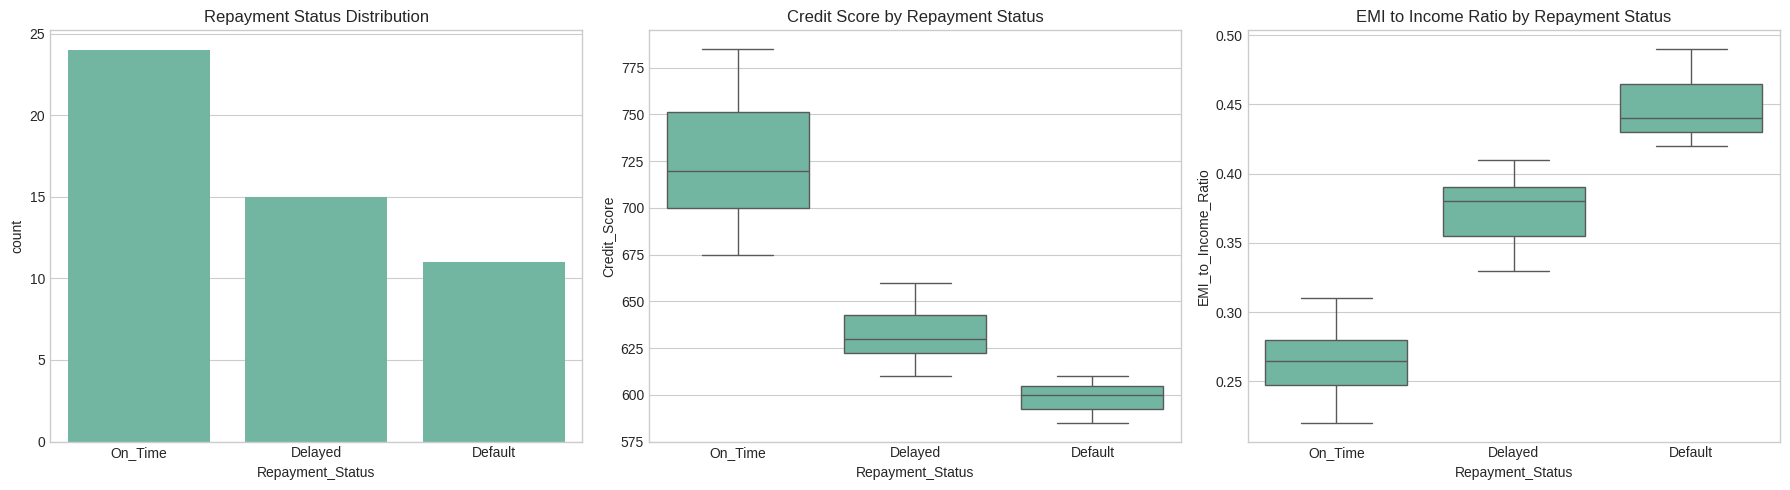

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Repayment_Status', ax=axes[0])
axes[0].set_title('Repayment Status Distribution')

sns.boxplot(data=df, x='Repayment_Status', y='Credit_Score', ax=axes[1])
axes[1].set_title('Credit Score by Repayment Status')

sns.boxplot(data=df, x='Repayment_Status', y='EMI_to_Income_Ratio', ax=axes[2])
axes[2].set_title('EMI to Income Ratio by Repayment Status')

plt.tight_layout()
plt.show()

#### Step 3: Data Preprocessing

In [ ]:
model_df = df.copy()

target_encoder = LabelEncoder()
model_df['Repayment_Status_Code'] = target_encoder.fit_transform(model_df['Repayment_Status'])

X = model_df.drop(columns=['Customer_ID', 'Repayment_Status', 'Repayment_Status_Code'])
X = pd.get_dummies(X, drop_first=True)
y = model_df['Repayment_Status_Code']

print('Encoded feature matrix shape:', X.shape)
print('Target classes:', list(target_encoder.classes_))
X.head()

Encoded feature matrix shape: (50, 14)
Target classes: ['Default', 'Delayed', 'On_Time']


,Age,Monthly_Income,Loan_Amount,Credit_Score,Employment_Years,Previous_Defaults,EMI_to_Income_Ratio,Region_North,Region_South,Region_West,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Medical,Loan_Purpose_Vehicle
0,25,32000,90000,690,2,0,0.22,True,False,False,True,False,False,False
1,29,38000,120000,710,4,0,0.28,False,True,False,False,False,False,True
2,41,52000,180000,640,8,1,0.38,False,False,False,False,False,False,False
3,35,47000,160000,605,6,1,0.42,False,False,True,False,False,True,False
4,31,44000,95000,735,5,0,0.24,True,False,False,False,True,False,False


#### Step 4: Train the Decision Tree Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tree_model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     Default       1.00      1.00      1.00         3
     Delayed       1.00      1.00      1.00         4
     On_Time       1.00      1.00      1.00         6

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



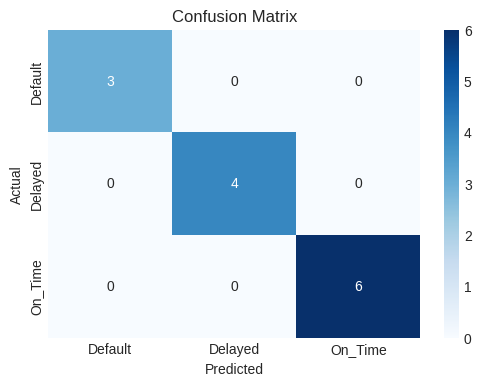

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Step 5: Use Decision Tree Leaves as Clusters

In [ ]:
df['Cluster_ID'] = tree_model.apply(X)

cluster_summary = df.groupby('Cluster_ID').agg(
    Customers=('Customer_ID', 'count'),
    Avg_Income=('Monthly_Income', 'mean'),
    Avg_Loan=('Loan_Amount', 'mean'),
    Avg_Credit_Score=('Credit_Score', 'mean'),
    Avg_EMI_Ratio=('EMI_to_Income_Ratio', 'mean')
).round(2)

dominant_status = df.groupby('Cluster_ID')['Repayment_Status'].agg(lambda x: x.value_counts().idxmax())
cluster_summary['Dominant_Repayment_Status'] = dominant_status
cluster_summary = cluster_summary.sort_values(by='Customers', ascending=False)

cluster_summary

,Customers,Avg_Income,Avg_Loan,Avg_Credit_Score,Avg_EMI_Ratio,Dominant_Repayment_Status
Cluster_ID,,,,,,
1,24,52395.83,165666.67,725.83,0.26,On_Time
3,15,46566.67,159866.67,633.33,0.37,Delayed
4,11,42181.82,165909.09,598.18,0.45,Default


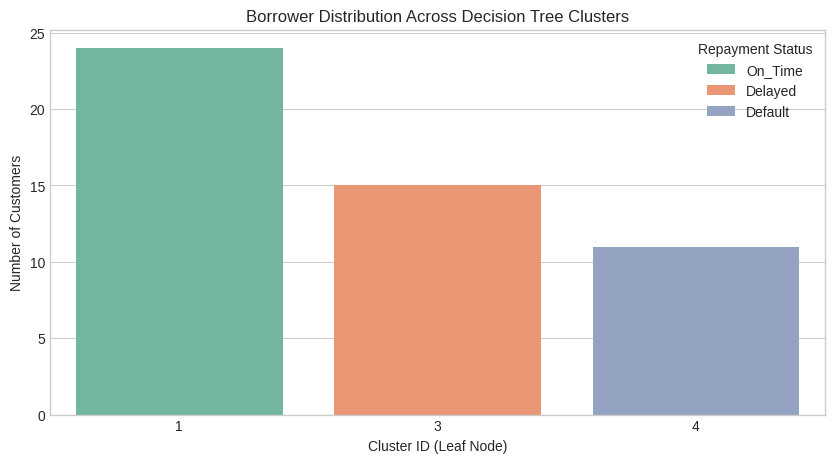

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Cluster_ID', hue='Repayment_Status')
plt.title('Borrower Distribution Across Decision Tree Clusters')
plt.xlabel('Cluster ID (Leaf Node)')
plt.ylabel('Number of Customers')
plt.legend(title='Repayment Status')
plt.show()

#### Step 6: Visualize the Decision Tree

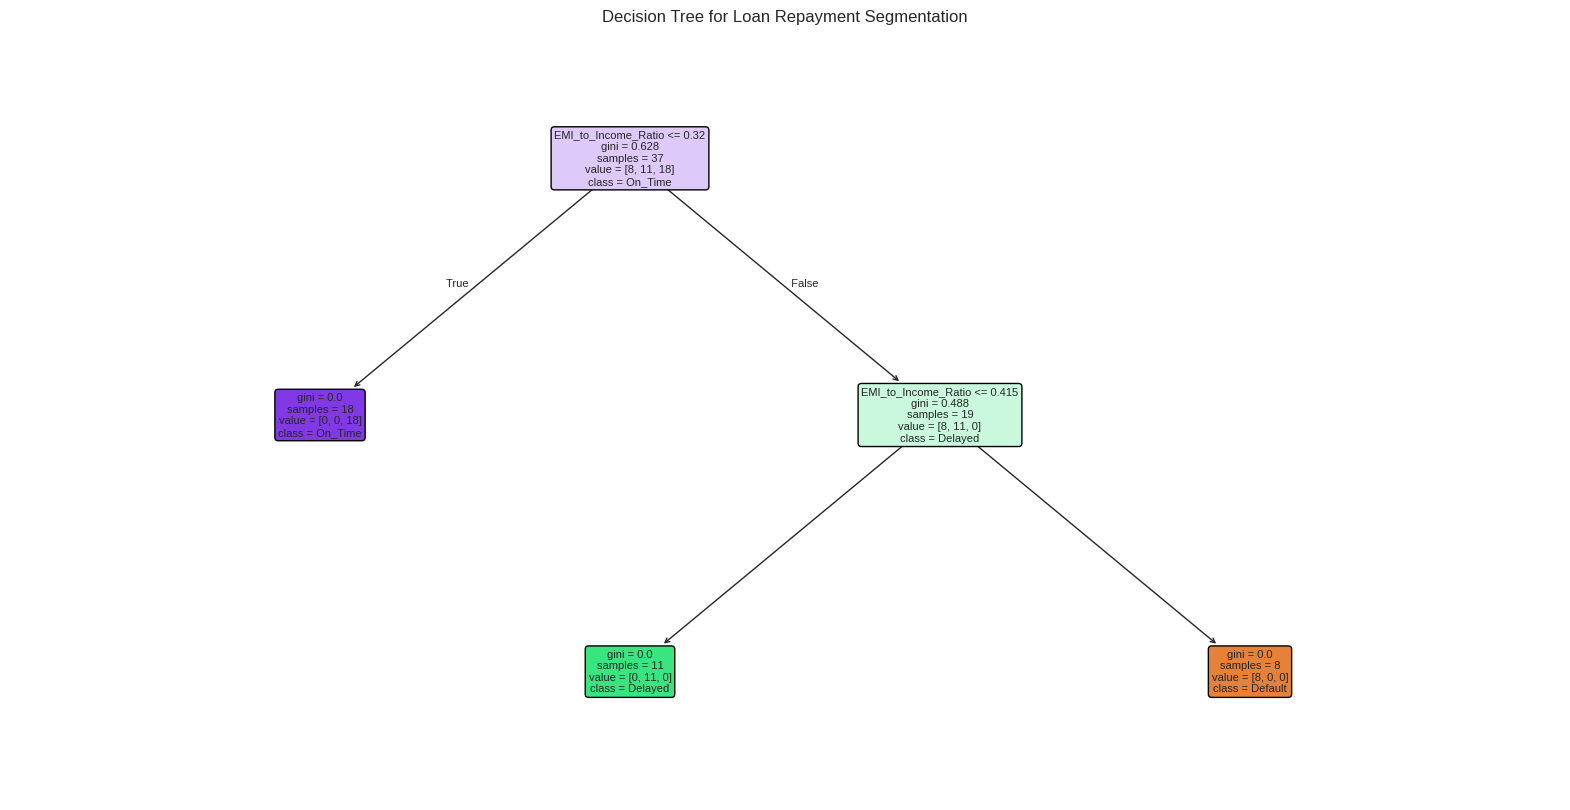

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree for Loan Repayment Segmentation')
plt.show()

#### Step 7: Business Intelligence Interpretation

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(feature_importance.head(10))

print('Key BI Insights:')
print('1. Higher credit scores are generally linked with On_Time repayment customers.')
print('2. Higher EMI to income ratios and previous defaults increase repayment risk.')
print('3. Decision tree leaves create clear borrower segments that can support policy decisions, marketing, and loan approval strategies.')

,Feature,Importance
6,EMI_to_Income_Ratio,1.0
0,Age,0.0
2,Loan_Amount,0.0
3,Credit_Score,0.0
4,Employment_Years,0.0
1,Monthly_Income,0.0
5,Previous_Defaults,0.0
7,Region_North,0.0
8,Region_South,0.0
9,Region_West,0.0


Key BI Insights:
1. Higher credit scores are generally linked with On_Time repayment customers.
2. Higher EMI to income ratios and previous defaults increase repayment risk.
3. Decision tree leaves create clear borrower segments that can support policy decisions, marketing, and loan approval strategies.
